In [1]:
import pandas as pd
import numpy as np
from numpy.random import seed
from numpy.random import shuffle
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from __future__ import print_function
import seaborn as sns
from matplotlib.ticker import NullFormatter, MaxNLocator
from pandas.plotting import scatter_matrix
import matplotlib.ticker as ticker
import plotly.graph_objects as go
import scipy as sp
from itertools import chain
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy import spatial
from scipy.spatial import ConvexHull
from scipy.optimize import curve_fit
import scipy.stats as stats
import statsmodels.stats.weightstats
from matplotlib import path
import matplotlib
from scipy.stats import probplot,shapiro, sem
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint
from scipy.interpolate import make_interp_spline
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import cm
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from numpy import linspace
#import pylab
import os
#import PIL
#from scipy.ndimage import gaussian_filter, uniform_filter1d

In [ ]:
PA_Y1_Y2_metadata_PCR_sero = pd.read_excel("PA Y1 and Y2 Metadata with PCR and Serology.xlsx", sheet_name="Sheet1")
PA_Y1_Y2_metadata_PCR_sero['Collection Date'] = pd.to_datetime(PA_Y1_Y2_metadata_PCR_sero['Harvest Date'], errors='coerce')


#Serology testing result is EITHER positive or negative. Drop all other results
PA_Y1_Y2_metadata_PCR_sero = PA_Y1_Y2_metadata_PCR_sero[PA_Y1_Y2_metadata_PCR_sero['Serology Testing Result'].isin(['Negative','Positive'])].copy()

#PCR testing result is EITHER positive or negative. Drop all other results
PA_Y1_Y2_metadata_PCR_sero = PA_Y1_Y2_metadata_PCR_sero[PA_Y1_Y2_metadata_PCR_sero['PCR Testing Result'].isin(['Negative','Positive'])].copy()

PA_Y1_Y2_metadata_PCR_sero


,Animal ID,Project Year,Referral,Agency,Collection Date,State,Check Station County,Species,Swab Type,# Nobutos,...,Age Class,Deer Harvest County,Harvest Type,Harvest Date,Comments,N1_CQ,N2_CQ,PCR Testing Result,Average % inh,Serology Testing Result
0,COV0011804,1,PALB120421,USDA-APHIS-Wildlife Services,2021-12-04,Pennsylvania,Franklin,WTD,Nasal,2,...,Adult,Franklin,Hunter,2021-12-04,LEAD#B228,NaN,NaN,Negative,11.440809,Negative
1,COV0011808,1,PALB120421,USDA-APHIS-Wildlife Services,2021-12-04,Pennsylvania,Franklin,WTD,Oral,2,...,Adult,Franklin,Hunter,2021-12-04,LEAD#B320,NaN,NaN,Negative,19.055757,Negative
2,COV0011811,1,PALB120421,USDA-APHIS-Wildlife Services,2021-12-04,Pennsylvania,Franklin,WTD,Nasal,2,...,Juvenile,Franklin,Hunter,2021-12-04,LEAD#19260,NaN,NaN,Negative,7.227480,Negative
3,COV0011812,1,PALB120421,USDA-APHIS-Wildlife Services,2021-12-04,Pennsylvania,Franklin,WTD,Nasal,2,...,Adult,Franklin,Hunter,2021-12-04,LEAD#B556,NaN,NaN,Negative,7.545158,Negative
4,COV0011814,1,PALB120421,USDA-APHIS-Wildlife Services,2021-12-04,Pennsylvania,Franklin,WTD,Nasal,2,...,Adult,Franklin,Hunter,2021-12-04,LEAD#B569,NaN,NaN,Negative,20.623148,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,COV0052815,2,PAAS121222C,USDA-APHIS-Wildlife Services,2022-12-10,Pennsylvania,Warren,WTD,Nasal,2,...,Adult,Berks,Hunter,2022-12-10,NaN,NaN,NaN,Negative,8.019721,Negative
1997,COV0052816,2,PAAS121222C,USDA-APHIS-Wildlife Services,2022-12-10,Pennsylvania,Warren,WTD,Nasal,2,...,Adult,Lebanon,Hunter,2022-12-10,NaN,NaN,NaN,Negative,7.270711,Negative
1998,COV0052817,2,PAAS121222C,USDA-APHIS-Wildlife Services,2022-12-10,Pennsylvania,Warren,WTD,Nasal,2,...,Adult,Lebanon,Hunter,2022-12-10,NaN,NaN,NaN,Negative,6.388416,Negative
2001,COV0052820,2,PAAS121222C,USDA-APHIS-Wildlife Services,2022-12-10,Pennsylvania,Warren,WTD,Nasal,2,...,Adult,Berks,Hunter,2022-12-10,NaN,NaN,NaN,Negative,11.519686,Negative


In [3]:
PA_Y1_Y2_metadata_PCR_sero.columns

Index(['Animal ID', 'Project Year', 'Referral', 'Agency', 'Collection Date',
       'State', 'Check Station County', 'Species', 'Swab Type', '# Nobutos',
       'Sex', 'Age Class', 'Deer Harvest County', 'Harvest Type',
       'Harvest Date', 'Comments', 'N1_CQ', 'N2_CQ', 'PCR Testing Result',
       'Average % inh', 'Serology Testing Result'],
      dtype='object')

In [4]:

vc = PA_Y1_Y2_metadata_PCR_sero['Deer Harvest County'].value_counts()
print(vc.to_string())
del vc


Allegheny         132
Delaware          124
Bucks             110
Montgomery        101
Dauphin            77
Monroe             75
Warren             71
Philadelphia       70
Lancaster          68
Cumberland         66
Pike               60
Franklin           54
Cambria            53
Jefferson          52
Perry              51
Adams              50
Washington         39
Greene             37
York               31
Indiana            28
Luzerne            26
Wayne              25
Lycoming           25
Crawford           23
Berks              22
Fayette            22
Schuylkill         18
Beaver             17
Huntingdon         17
Clearfield         16
Lebanon            15
Centre             12
Tioga              12
Mercer             12
Forest             11
Mifflin            11
Columbia            9
Erie                9
Carbon              8
Bedford             8
Butler              7
Lawrence            7
Blair               7
Potter              7
Westmoreland        6
Somerset  

In [5]:
PA_Y1_Y2_metadata_PCR_sero["MonthYear"] = PA_Y1_Y2_metadata_PCR_sero["Collection Date"].dt.to_period("M").dt.to_timestamp()

PA_Y1_Y2_metadata_PCR_sero["Semester"] = np.where(
    PA_Y1_Y2_metadata_PCR_sero["MonthYear"].dt.month.isin([9, 10, 11, 12]),       
    "Fall "   + PA_Y1_Y2_metadata_PCR_sero["MonthYear"].dt.year.astype(str),
    np.where(
        PA_Y1_Y2_metadata_PCR_sero["MonthYear"].dt.month.isin([1, 2, 3, 4]),         
        "Spring " + PA_Y1_Y2_metadata_PCR_sero["MonthYear"].dt.year.astype(str),
        'out_of_season'                                               
    )
)

PA_Y1_Y2_metadata_PCR_sero = PA_Y1_Y2_metadata_PCR_sero.sort_values("MonthYear").copy()

PA_Y1_Y2_metadata_PCR_sero = PA_Y1_Y2_metadata_PCR_sero[PA_Y1_Y2_metadata_PCR_sero['Semester']!='out_of_season']


In [8]:
PA_Y1_Y2_metadata_PCR_sero[PA_Y1_Y2_metadata_PCR_sero['Semester'].isin(['Fall 2022.0','Spring 2023.0'])]['PCR Testing Result'].value_counts()

Negative    824
Positive    168
Name: PCR Testing Result, dtype: int64

In [21]:
237/(237+755)

0.23891129032258066

In [6]:
PA_Y1_Y2_metadata_PCR_sero['Semester'].value_counts()

Fall 2022.0      698
Fall 2021.0      420
Spring 2022.0    340
Spring 2023.0    294
Name: Semester, dtype: int64

# 1. compute 95% Wilson CI

In [10]:
# Copy and keep your same preprocessing
df = PA_Y1_Y2_metadata_PCR_sero.copy()
df["PCR Positive"] = df["PCR Testing Result"].str.lower() == "positive"
df["Seropositive"] = df["Serology Testing Result"].str.lower() == "positive"

# Monthly counts (successes and totals) for each test type
counts = (
    df.groupby(["MonthYear"])
      .agg(
          PCR_pos=("PCR Positive", "sum"),
          PCR_n  =("PCR Positive", "count"),
          Sero_pos=("Seropositive", "sum"),
          Sero_n  =("Seropositive", "count"),
      )
      .reset_index()
)

# Wilson CI function (z = 1.96 for ~95% CI)
z = 1.96
def wilson_bounds(x, n, z=1.96):
    x = np.asarray(x, dtype=float)
    n = np.asarray(n, dtype=float)
    phat = np.divide(x, n, out=np.full_like(n, np.nan, dtype=float), where=n>0)
    denom = 1.0 + (z**2)/n
    center = (phat + (z**2)/(2*n)) / denom
    half = (z * np.sqrt( (phat*(1 - phat))/n + (z**2)/(4*(n**2)) )) / denom
    lower = center - half
    upper = center + half
    return lower, upper, phat

# Compute Wilson CIs for PCR
pcr_low, pcr_high, pcr_mean = wilson_bounds(counts["PCR_pos"], counts["PCR_n"], z=z)

# Compute Wilson CIs for Serology
sero_low, sero_high, sero_mean = wilson_bounds(counts["Sero_pos"], counts["Sero_n"], z=z)

# Build a long dataframe aligned with your plotting style
pcr_df = pd.DataFrame({
    "MonthYear": counts["MonthYear"],
    "Test_Type": "PCR Positive",
    "Mean": pcr_mean,
    "CI_low": pcr_low,
    "CI_high": pcr_high,
    "n_samples": counts["PCR_n"],  # per-month PCR sample size
})

sero_df = pd.DataFrame({
    "MonthYear": counts["MonthYear"],
    "Test_Type": "Seropositive",
    "Mean": sero_mean,
    "CI_low": sero_low,
    "CI_high": sero_high,
    "n_samples": counts["Sero_n"],  # per-month serology sample size
})

melted_ci = (
    pd.concat([pcr_df, sero_df], ignore_index=True)
      .sort_values(["Test_Type", "MonthYear"])
      .reset_index(drop=True)
)

# (Optional) If you also want a wide table similar to your 'grouped' with means:
grouped_ci = (
    counts.assign(
        PCR_Positive_Mean = pcr_mean,
        PCR_CI_low = pcr_low,
        PCR_CI_high = pcr_high,
        Seropositive_Mean = sero_mean,
        Sero_CI_low = sero_low,
        Sero_CI_high = sero_high,
    )
)

print("Computed Wilson 95% CIs. DataFrames available:")
print(" - melted_ci: MonthYear, Test_Type, Mean, CI_low, CI_high, n_samples")
print(" - grouped_ci: per-month counts + means and CI bounds")


Computed Wilson 95% CIs. DataFrames available:
 - melted_ci: MonthYear, Test_Type, Mean, CI_low, CI_high, n_samples
 - grouped_ci: per-month counts + means and CI bounds


adjusting for publication
must make sure left and right sample size are same limits, removing one redundant label
must make sure left and right ylabel are same, removing one redundant label


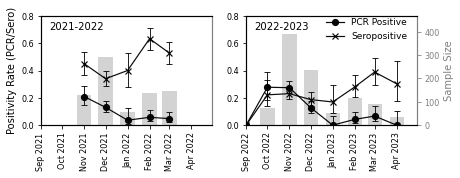

In [19]:
print("adjusting for publication")
print("must make sure left and right sample size are same limits, removing one redundant label")
print("must make sure left and right ylabel are same, removing one redundant label")

df = PA_Y1_Y2_metadata_PCR_sero.copy()


df["PCR Positive"]  = df["PCR Testing Result"].str.lower() == "positive"
df["Seropositive"]  = df["Serology Testing Result"].str.lower() == "positive"


grouped = (
    df.groupby([ "MonthYear"])
      .agg(PCR_Positive_Mean=("PCR Positive","mean"),
           Seropositive_Mean=("Seropositive","mean"),
           n_samples        =("PCR Positive","size"))
      .reset_index()
)

# 3. Melt to long form, keeping n_samples
melted = (
    grouped.melt(
        id_vars=["MonthYear","n_samples"],
        value_vars=["PCR_Positive_Mean","Seropositive_Mean"],
        var_name="Test_Type", value_name="Mean"
    )
    .assign(Test_Type=lambda d: d["Test_Type"]
                               .str.replace("_Mean","")
                               .str.replace("_"," "))
)

# 4. Setup figure and axes

ncols  = 2
nrows  = 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5, 2.5))

ax_left, ax_right = axes

mask_top    = (melted["MonthYear"] >= pd.Timestamp("2021-09-01")) & \
              (melted["MonthYear"] <= pd.Timestamp("2022-04-30"))

mask_bottom = (melted["MonthYear"] >= pd.Timestamp("2022-09-01")) & \
              (melted["MonthYear"] <= pd.Timestamp("2023-04-30"))


colors = {"PCR Positive":"black","Seropositive":"black"}
markers_ = {"PCR Positive":"o","Seropositive":"x"}
# 5. Plot each block with segmentation + grey bars

ax = ax_left
ax2 = ax.twinx()
sub = melted.loc[mask_top].copy()  # <-- place BEFORE the gray bar line
ax2.set_ylim(0, melted['n_samples'].max()*1.2)



# Grey bars for sample size
ax2.bar(sub["MonthYear"], sub["n_samples"],
        width=20, color="lightgrey")

#ax2.set_ylabel("Sample Size", color="grey", fontsize=10)
#ax2.tick_params(axis="y", colors="grey", labelsize=8)
ax2.set_yticks([])
ax2.grid(False)
ax2.set_zorder(0)
ax.set_zorder(1)
ax.patch.set_visible(False)

MIN_N = 1
melted_keep = melted_ci[melted_ci["n_samples"] > MIN_N].copy()


# For each test type, break into segments
for test in ["PCR Positive","Seropositive"]:
    data = (sub[sub["Test_Type"] == test]
            .sort_values("MonthYear")
            .reset_index(drop=True))
    # identify gaps >120 days
    seg_id = (data["MonthYear"].diff() > pd.Timedelta(days=120)).cumsum()

    for _, seg in data.groupby(seg_id):
        ax.plot(seg["MonthYear"], seg["Mean"],markerfacecolor="black",
                markeredgecolor=colors[test], markeredgewidth=1.2,
                marker=markers_[test], lw=1.2, color=colors[test],alpha=0.95,
                label=test if (test not in ax.get_legend_handles_labels()[1]) else None)

        seg_with_ci = (
            melted_ci[melted_ci["Test_Type"] == test]
            .merge(seg[["MonthYear"]], on="MonthYear", how="inner")
            .sort_values("MonthYear")
        )
        mask = seg_with_ci["n_samples"] > 1
        ax.errorbar(
            seg_with_ci.loc[mask, "MonthYear"],
            seg_with_ci.loc[mask, "Mean"],
            yerr=np.vstack([
                seg_with_ci.loc[mask, "Mean"] - seg_with_ci.loc[mask, "CI_low"],
                seg_with_ci.loc[mask, "CI_high"] - seg_with_ci.loc[mask, "Mean"]
            ]),
            fmt='none', lw=1, alpha=0.85, ecolor=colors[test], capsize=3
        )

for sp in ['top', 'left', 'bottom']:
    ax.spines[sp].set_linewidth(1.2)
ax.spines['right'].set_color('grey')    
ax.spines['right'].set_linewidth(1.2)    
#ax2.spines['right'].set_color('lightgrey')    
#ax2.spines['right'].set_linewidth(1)    

#if i % ncols == 0:
ax.set_ylabel("Positivity Rate (PCR/Sero)",fontsize=10)

ax.set_ylim(0, 0.8)
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
left_xmin = pd.Timestamp("2021-09-01")
left_xmax = pd.Timestamp("2022-04-30")
ax_left.set_xlim(left_xmin, left_xmax)

ax_left.text(0.05, 0.95, '2021-2022', transform=ax_left.transAxes,
             verticalalignment='top', horizontalalignment='left', fontsize=10)
        
ax = ax_right
ax2 = ax.twinx()
sub = melted.loc[mask_bottom].copy()  # <-- place BEFORE the gray bar line
ax2.set_ylim(0, sub['n_samples'].max()*1.2)
    
    
# Grey bars for sample size
ax2.bar(sub["MonthYear"], sub["n_samples"],
        width=20, color="lightgrey")

ax2.set_ylabel("Sample Size", color="grey", fontsize=10)
ax2.tick_params(axis="y", colors="grey", labelsize=8)
ax2.grid(False)
ax2.set_zorder(0)
ax.set_zorder(1)
ax.patch.set_visible(False)

MIN_N = 1
melted_keep = melted_ci[melted_ci["n_samples"] > MIN_N].copy()


# For each test type, break into segments
for test in ["PCR Positive","Seropositive"]:
    data = (sub[sub["Test_Type"] == test]
            .sort_values("MonthYear")
            .reset_index(drop=True))
    # identify gaps >120 days
    seg_id = (data["MonthYear"].diff() > pd.Timedelta(days=120)).cumsum()

    for _, seg in data.groupby(seg_id):
        ax.plot(seg["MonthYear"], seg["Mean"],markerfacecolor="black",
                markeredgecolor=colors[test], markeredgewidth=1.2,
                marker=markers_[test], lw=1.2, color=colors[test],alpha=0.95,
                label=test if (test not in ax.get_legend_handles_labels()[1]) else None)

        seg_with_ci = (
            melted_ci[melted_ci["Test_Type"] == test]
            .merge(seg[["MonthYear"]], on="MonthYear", how="inner")
            .sort_values("MonthYear")
        )
        mask = seg_with_ci["n_samples"] > 1
        ax.errorbar(
            seg_with_ci.loc[mask, "MonthYear"],
            seg_with_ci.loc[mask, "Mean"],
            yerr=np.vstack([
                seg_with_ci.loc[mask, "Mean"] - seg_with_ci.loc[mask, "CI_low"],
                seg_with_ci.loc[mask, "CI_high"] - seg_with_ci.loc[mask, "Mean"]
            ]),
            fmt='none', lw=1, alpha=0.85, ecolor=colors[test], capsize=3
        )

right_xmin = pd.Timestamp("2022-09-01")
right_xmax = pd.Timestamp("2023-04-30")
ax_right.set_xlim(right_xmin, right_xmax)

# Formatting
#ax.set_title(f"Location = Pennsylvania: All Sampled Counties", fontsize=14)


for sp in ['top', 'left', 'bottom']:
    ax.spines[sp].set_linewidth(1.2)
ax.spines['right'].set_color('grey')    
ax.spines['right'].set_linewidth(1.2)    
#ax2.spines['right'].set_color('lightgrey')    
#ax2.spines['right'].set_linewidth(1)    

#if i % ncols == 0:
#ax.set_ylabel("Positivity Rate (PCR/Sero)",fontsize=10)

ax.set_ylim(0, 0.8)
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax_right.text(0.05, 0.95, '2022-2023', transform=ax_right.transAxes,
              verticalalignment='top', horizontalalignment='left', fontsize=10)    


# Global legend for the two tests
handles, labels = ax_left.get_legend_handles_labels()
fig.legend(handles, labels, frameon=False,fontsize=9,
           loc=(0.70,0.75))

fig.tight_layout()
plt.show()

del df

fig.savefig('./PCR_sero_monthly_changes.png',format='png',dpi=1000,bbox_inches='tight')
